# 04 — Machine learning on the corn–soybean spread

Instead of a fixed z-score rule, we ask a classifier: **if we buy the spread today, will the trade end in profit?**
The pipeline follows López de Prado, *Advances in Financial Machine Learning* (AFML):

| Step | What | AFML | Code |
|---|---|---|---|
| Hedge & spread | 504-day rolling OLS (for labels); 3-state Kalman filter with an AR(1) spread state (features) | — | `features.py` |
| Labels | Triple barrier on the P&L of a long-spread trade with the hedge frozen at entry | Ch. 3 | `labels.py` |
| Sample weights | Average uniqueness of overlapping labels | Ch. 4 | `labels.py` |
| Features | Kalman spread and z-scores, spread volatility, calendar, 90 rolling weather variables (US Corn Belt + Brazil) | — | `ml.py` |
| Validation | Final 375-observation holdout touched once; walk-forward purged CV on the rest | Ch. 7, 11 | `cv.py` |
| Selection | MDI ∪ MDA top-20, veto negative MDA | Ch. 8 | `cv.py`, `ml.py` |
| Models | XGBoost; random forest on sequentially bootstrapped bags | Ch. 4, 6 | `ml.py` |
| Tuning | Grid search on walk-forward neg log-loss | Ch. 9 | `ml.py` |
| Backtest | Probability- or sign-based sizing, daily or monthly rebalancing | Ch. 10 | `backtest.py`, `betsize.py` |

**Why walk-forward CV and not purged k-fold?** The rolling OLS and Kalman features are estimated sequentially from
past prices. Symmetric k-fold would train on periods *after* the test fold, whose features were computed from
test-fold prices — a leak that purging does not remove. Walk-forward only ever trains on the past.

Data: CORN and SOYB ETFs with US and Brazilian weather, 2011–2026 (notebook 01).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix
from xgboost import XGBClassifier

from src.data import load_full_dataset, weather_columns, save_figure, save_table
from src.cv import temporal_split, WalkForwardPurgedCV, cv_score, feat_importance_mda, feat_importance_mdi
from src.ml import (pair_frame, pair_labels, assemble_xy, select_features, make_xgb,
                    tune_xgb, tune_pipeline, SeqBootstrapRF)
from src.betsize import compute_position_prob, compute_position_budget
from src.backtest import run_backtest, performance, market_neutrality

np.random.seed(42)                       # MDA permutations use np.random

df = load_full_dataset(['corn', 'soybean'])
WEATHER = weather_columns(df, ['corn', 'soybean'])
DEP, IND = 'close_soybean', 'close_corn'  # soybean = alpha + gamma * corn + spread
N_HOLDOUT = 375                           # ~1.5 years, touched once at the end
print(f'{len(df)} trading days ({df.index[0].date()} to {df.index[-1].date()}), {len(WEATHER)} weather features')

3670 trading days (2011-09-19 to 2026-04-23), 90 weather features


## 1. Features and labels

**Three-state Kalman filter.** The usual two-state filter (Chan) treats the spread as iid noise, so a temporarily wide
spread is "explained" by moving the hedge ratio. We add the spread as a third hidden state with AR(1) dynamics,
$\xi_t = [\alpha_t, \gamma_t, s_t]$, $F = \mathrm{diag}(1, 1, \phi)$; $\phi$ and the spread innovation variance are
re-estimated iteratively, leaving the hedge-ratio drift $\delta$ as the only hyperparameter (tuned in section 5).

**Triple-barrier labels.** For an entry on every day, the P&L of a long-spread position with the hedge frozen at entry,
$(S_t - S_{t_0}) - \gamma_{t_0}(C_t - C_{t_0})$, is followed until it hits $\pm$ `pt_sl` × daily volatility or until
`num_days` trading days have passed; the label is the sign of the P&L at that moment. Labels overlap heavily, so each
observation is weighted by its average uniqueness.

In [2]:
d = pair_frame(df, DEP, IND, WEATHER, delta=1e-6, verbose=True)
labels, weights = pair_labels(d, DEP, IND, num_days=200, pt_sl=2.5)
print(f'\nLabelled events: {len(labels)}, label counts {labels["bin"].value_counts().to_dict()}, '
      f'mean uniqueness {weights.mean():.3f}')

X, y, t1, w = assemble_xy(d, labels, weights)
print(f'Features: {X.shape[1]}  (Kalman: {[c for c in X if c.startswith("kf_")]}, '
      f'other: {[c for c in X if not c.startswith("kf_") and "_roll" not in c]})')
split = temporal_split(X, y, t1, sample_weight=w, n_holdout=N_HOLDOUT)

Rolling OLS (504d): valid rows 3166 / 3670, hedge ratio -0.099 to 1.394


Kalman (delta=1e-06): converged in 4 iterations, phi=0.99410 (half-life 117 days), gamma 0.279 to 0.650, innovation-z std 1.104 (ideal 1)



Labelled events: 2966, label counts {1: 1545, -1: 1421}, mean uniqueness 0.088
Features: 97  (Kalman: ['kf_spread', 'kf_innovation', 'kf_z_score', 'kf_level_z'], other: ['month', 'day_of_week', 'spread_vol'])
Dev set:      2587 obs  (2013-09-20 → 2023-12-29)
Holdout set:   375 obs  (2024-01-08 → 2025-07-08)
Cutoff date: 2024-01-08  (4 dev obs purged: label resolved inside the holdout)
Dev label dist:     {0: 1219, 1: 1368}
Holdout label dist: {0: 198, 1: 177}


## 2. Baselines: 6 features vs all 97 features

XGBoost with default-ish, strongly regularised parameters. Walk-forward CV with 3 periods = 2 test folds.

In [3]:
model = XGBClassifier(n_estimators=300, max_depth=2, learning_rate=0.1, min_child_weight=15,
                      eval_metric='logloss', random_state=42)

def walk_forward(features, scoring='accuracy'):
    cv = WalkForwardPurgedCV(n_periods=3, t1=split['t1_dev'])
    return cv_score(model, split['X_dev'][features], split['y_dev'], split['t1_dev'],
                    sample_weight=split['w_dev'], cv=cv, scoring=scoring)

baseline_cols = ['kf_level_z', 'kf_z_score', 'kf_spread', 'spread_vol', 'month', 'day_of_week']
print('=== 6 features — accuracy ===');  res_base = walk_forward(baseline_cols)
print('\n=== 97 features — accuracy ===');  res_full = walk_forward(list(X.columns))
print('\n=== 97 features — neg log-loss ==='); res_full_ll = walk_forward(list(X.columns), 'neg_log_loss')

=== 6 features — accuracy ===


Fold    Train   Test  Purged               Train Dates                Test Dates  Train Score  Test Score
---------------------------------------------------------------------------------------------------------
1         852    862      10   2013-09-20 → 2017-02-15   2017-02-23 → 2020-07-27       0.5540      0.4745
2        1716    863       8   2013-09-20 → 2020-07-15   2020-07-28 → 2023-12-29       0.5839      0.5238
---------------------------------------------------------------------------------------------------------
Mean                                                                                   0.5690      0.4991
Std                                                                                    0.0150      0.0246

=== 97 features — accuracy ===


Fold    Train   Test  Purged               Train Dates                Test Dates  Train Score  Test Score
---------------------------------------------------------------------------------------------------------
1         852    862      10   2013-09-20 → 2017-02-15   2017-02-23 → 2020-07-27       0.5540      0.4745
2        1716    863       8   2013-09-20 → 2020-07-15   2020-07-28 → 2023-12-29       0.6766      0.6176
---------------------------------------------------------------------------------------------------------
Mean                                                                                   0.6153      0.5460
Std                                                                                    0.0613      0.0716

=== 97 features — neg log-loss ===


Fold    Train   Test  Purged               Train Dates                Test Dates  Train Score  Test Score
---------------------------------------------------------------------------------------------------------
1         852    862      10   2013-09-20 → 2017-02-15   2017-02-23 → 2020-07-27      -0.6890     -0.6970
2        1716    863       8   2013-09-20 → 2020-07-15   2020-07-28 → 2023-12-29      -0.5911     -0.6584
---------------------------------------------------------------------------------------------------------
Mean                                                                                  -0.6400     -0.6777
Std                                                                                    0.0489      0.0193


## 3. Feature importance and selection (AFML Ch. 8)

* **MDA** (out-of-sample, permutation): how much does walk-forward neg log-loss drop when a feature is shuffled?
  Negative values mean the model does *better* without the feature.
* **MDI** (in-sample, impurity): random forest with `max_features=1` to avoid masking.

Selection rule: union of both top-20 lists, minus any feature with negative MDA.

In [4]:
cv = WalkForwardPurgedCV(n_periods=3, t1=split['t1_dev'])
mda = feat_importance_mda(model, split['X_dev'], split['y_dev'], split['t1_dev'],
                          sample_weight=split['w_dev'], cv=cv)
mdi = feat_importance_mdi(split['X_dev'], split['y_dev'], sample_weight=split['w_dev'])
selected, vetoed = select_features(mdi, mda, top_n=20)

print(f'Positive MDA: {(mda["mean"] > 0).sum()} / {len(mda)} features')
print(f'Selected {len(selected)} features; vetoed (in a top-20 but negative MDA): {vetoed}')
ranks = pd.DataFrame({'MDI rank': mdi.index.get_indexer(selected) + 1,
                      'MDA rank': mda.index.get_indexer(selected) + 1,
                      'MDA': mda.loc[selected, 'mean'].values}, index=selected).sort_values('MDA rank')
ranks.head(15)

Positive MDA: 17 / 97 features
Selected 32 features; vetoed (in a top-20 but negative MDA): ['temperature_2m_mean_mato_grosso_roll30d_mean', 'temperature_2m_min_mato_grosso_roll30d_mean']


,MDI rank,MDA rank,MDA
kf_level_z,2,1,0.012862
soil_moisture_28_to_100cm_mean_central_iowa_roll30d_min,7,2,0.012088
wind_speed_10m_max_central_iowa_roll30d_max,85,3,0.010364
temperature_2m_max_mato_grosso_roll30d_mean,15,4,0.009572
precipitation_sum_central_indiana_roll30d_sum,28,5,0.009383
vapour_pressure_deficit_max_parana_roll30d_mean,8,6,0.003902
soil_moisture_28_to_100cm_mean_parana_roll30d_min,26,7,0.002773
soil_moisture_7_to_28cm_mean_rio_grande_sul_roll30d_min,68,8,0.001588
wind_speed_10m_max_parana_roll30d_max,72,9,0.001446
soil_moisture_0_to_7cm_mean_rio_grande_sul_roll30d_min,53,10,0.001261


In [5]:
print('=== selected features — accuracy ===');     res_sel = walk_forward(selected)
print('\n=== selected features — neg log-loss ==='); res_sel_ll = walk_forward(selected, 'neg_log_loss')

=== selected features — accuracy ===


Fold    Train   Test  Purged               Train Dates                Test Dates  Train Score  Test Score
---------------------------------------------------------------------------------------------------------
1         852    862      10   2013-09-20 → 2017-02-15   2017-02-23 → 2020-07-27       0.5540      0.4745
2        1716    863       8   2013-09-20 → 2020-07-15   2020-07-28 → 2023-12-29       0.6678      0.6165
---------------------------------------------------------------------------------------------------------
Mean                                                                                   0.6109      0.5455
Std                                                                                    0.0569      0.0710

=== selected features — neg log-loss ===


Fold    Train   Test  Purged               Train Dates                Test Dates  Train Score  Test Score
---------------------------------------------------------------------------------------------------------
1         852    862      10   2013-09-20 → 2017-02-15   2017-02-23 → 2020-07-27      -0.6890     -0.6970
2        1716    863       8   2013-09-20 → 2020-07-15   2020-07-28 → 2023-12-29      -0.6078     -0.6445
---------------------------------------------------------------------------------------------------------
Mean                                                                                  -0.6484     -0.6707
Std                                                                                    0.0406      0.0262


## 4. Random forest with sequential bootstrap (AFML Ch. 4.5)

Mean uniqueness is below 0.1: every label overlaps with ~10 others, so a standard bootstrap produces near-identical
bags and highly correlated trees. Each tree is instead fit on a bag drawn in proportion to uniqueness, of size
(mean uniqueness × number of events).

In [6]:
X_dev, y_dev, t1_dev, w_dev = (split[k] for k in ['X_dev', 'y_dev', 't1_dev', 'w_dev'])
rows = []
for fold, (tr, te) in enumerate(WalkForwardPurgedCV(n_periods=3, t1=t1_dev).split(X_dev)):
    Xtr, Xte = X_dev[selected].iloc[tr], X_dev[selected].iloc[te]
    rf = SeqBootstrapRF(n_trees=200).fit(Xtr, y_dev.iloc[tr], w_dev.iloc[tr], t1_dev.iloc[tr], df.index)
    xgb = clone(model).fit(Xtr.values, y_dev.iloc[tr].values, sample_weight=w_dev.iloc[tr].values)
    for name, p in [('seq. bootstrap RF', rf.predict_proba(Xte)), ('XGBoost', xgb.predict_proba(Xte.values))]:
        rows.append({'fold': fold + 1, 'model': name, 'bag size': rf.bag_size_,
                     'accuracy': accuracy_score(y_dev.iloc[te], p[:, 1] >= 0.5),
                     'neg log-loss': -log_loss(y_dev.iloc[te], p)})
pd.DataFrame(rows).set_index(['fold', 'model']).round(4)

bag size  accuracy  neg log-loss
fold model                                              
1    seq. bootstrap RF        69    0.4849       -0.7688
     XGBoost                  69    0.4745       -0.6970
2    seq. bootstrap RF       132    0.5805       -0.6753
     XGBoost                 132    0.6165       -0.6445

## 5. Hyperparameter tuning (AFML Ch. 9), dev set only

Scored by walk-forward **neg log-loss**, which rewards well-calibrated probabilities rather than just the right side.

1. XGBoost: 525 combinations of depth, learning rate, number of trees and minimum child weight.
2. Pipeline: Kalman drift $\delta$, vertical barrier and barrier width — these require rebuilding features/labels.

In [7]:
xgb_table = tune_xgb(X_dev[selected], y_dev, t1_dev, w_dev)
best_xgb = xgb_table.iloc[0].to_dict()
xgb_table.head(8).round(4)

,max_depth,learning_rate,n_estimators,min_child_weight,train_nll,test_nll,gap
0,2,0.1,300,15,-0.6484,-0.6707,0.0223
1,5,0.1,300,15,-0.6484,-0.6707,0.0223
2,4,0.1,300,15,-0.6484,-0.6707,0.0223
3,6,0.1,300,15,-0.6484,-0.6707,0.0223
4,3,0.1,300,15,-0.6484,-0.6707,0.0223
5,4,0.1,200,15,-0.6484,-0.6707,0.0223
6,5,0.1,200,15,-0.6484,-0.6707,0.0223
7,3,0.1,200,15,-0.6484,-0.6707,0.0223


In [8]:
pipe_table = tune_pipeline(df, DEP, IND, WEATHER, selected, best_xgb, n_holdout=N_HOLDOUT)
best_pipe = pipe_table.iloc[0].to_dict()
pipe_table.round(4)

,delta,num_days,pt_sl,n_events,train_nll,test_nll,gap
0,0.0000,200,2.5,2966,-0.6484,-0.6707,0.0223
1,0.0000,200,2.5,2966,-0.6517,-0.6729,0.0212
2,0.0000,150,2.5,3016,-0.6455,-0.6735,0.0280
3,0.0001,200,2.5,2966,-0.6552,-0.6744,0.0192
4,0.0000,150,2.5,3016,-0.6505,-0.6755,0.0250
5,0.0001,150,2.5,3016,-0.6524,-0.6777,0.0254
6,0.0000,200,2.0,2966,-0.6381,-0.6779,0.0398
7,0.0000,150,2.0,3016,-0.6373,-0.6780,0.0407
8,0.0001,200,2.0,2966,-0.6460,-0.6807,0.0346
9,0.0000,200,2.0,2966,-0.6431,-0.6831,0.0400


## 6. Final holdout evaluation (touched once)

Rebuild features and labels with the best pipeline configuration, train on the full dev set, predict the holdout.
Reference points: a coin flip has accuracy 0.5 and log-loss $\ln 2 = 0.693$.

In [9]:
print('XGBoost:', {k: best_xgb[k] for k in ['max_depth', 'learning_rate', 'n_estimators', 'min_child_weight']})
print('Pipeline:', {k: best_pipe[k] for k in ['delta', 'num_days', 'pt_sl']})

d_final = pair_frame(df, DEP, IND, WEATHER, delta=best_pipe['delta'])
labels_f, weights_f = pair_labels(d_final, DEP, IND, int(best_pipe['num_days']), best_pipe['pt_sl'])
X_f, y_f, t1_f, w_f = assemble_xy(d_final, labels_f, weights_f, selected)
sp = temporal_split(X_f, y_f, t1_f, sample_weight=w_f, n_holdout=N_HOLDOUT)

final_xgb = make_xgb(best_xgb).fit(sp['X_dev'].values, sp['y_dev'].values, sample_weight=sp['w_dev'].values)
final_rf = SeqBootstrapRF(n_trees=200).fit(sp['X_dev'], sp['y_dev'], sp['w_dev'], sp['t1_dev'], df.index)

holdout_probs = {'XGBoost': final_xgb.predict_proba(sp['X_holdout'].values),
                 'seq. bootstrap RF': final_rf.predict_proba(sp['X_holdout'])}
y_ho = sp['y_holdout']
holdout = pd.DataFrame({name: {'accuracy': accuracy_score(y_ho, p[:, 1] >= 0.5), 'log-loss': log_loss(y_ho, p)}
                        for name, p in holdout_probs.items()}).T
holdout.loc['always majority class'] = [max(y_ho.mean(), 1 - y_ho.mean()), np.nan]
holdout.loc['coin flip'] = [0.5, np.log(2)]
save_table(holdout, '04_ml_holdout_classification')
print('Confusion matrix XGBoost (rows = actual 0/1, columns = predicted 0/1):')
print(confusion_matrix(y_ho, holdout_probs['XGBoost'][:, 1] >= 0.5))
holdout.round(4)

XGBoost: {'max_depth': 2.0, 'learning_rate': 0.1, 'n_estimators': 300.0, 'min_child_weight': 15.0}
Pipeline: {'delta': 1e-06, 'num_days': 200.0, 'pt_sl': 2.5}


Dev set:      2587 obs  (2013-09-20 → 2023-12-29)
Holdout set:   375 obs  (2024-01-08 → 2025-07-08)
Cutoff date: 2024-01-08  (4 dev obs purged: label resolved inside the holdout)
Dev label dist:     {0: 1219, 1: 1368}
Holdout label dist: {0: 198, 1: 177}


Confusion matrix XGBoost (rows = actual 0/1, columns = predicted 0/1):
[[ 85 113]
 [ 38 139]]


,accuracy,log-loss
XGBoost,0.5973,0.7181
seq. bootstrap RF,0.5120,0.6876
always majority class,0.5280,NaN
coin flip,0.5000,0.6931


## 7. Backtest on the holdout

The model's $P(\text{long spread profitable})$ is turned into a single spread position, re-set every day or on the
first trading day of each month, with the Kalman hedge ratio frozen between rebalances:

* **prob** — size $2\Phi(z)-1$ with $z = (p-0.5)/\sqrt{p(1-p)}$ (AFML §10.3);
* **sign** — full long if $p \ge 0.5$, full short otherwise.

First, the target positions implied by AFML's two bet-sizing schemes (averaging all active bets, §10.3–10.4, versus
concurrency budgeting, §10.2) — these show how much the sizing rule alone changes the exposure.

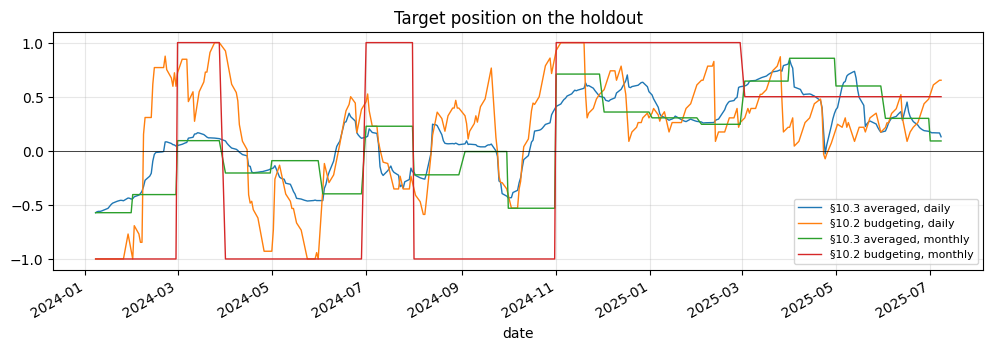

In [10]:
prob_holdout = pd.Series(holdout_probs['XGBoost'][:, 1], index=sp['X_holdout'].index)
holdout_idx = prob_holdout.index

fig, ax = plt.subplots(figsize=(12, 3.5))
for freq in ['daily', 'monthly']:
    compute_position_prob(prob_holdout, sp['t1_holdout'], holdout_idx, freq).plot(ax=ax, lw=1, label=f'§10.3 averaged, {freq}')
    compute_position_budget(prob_holdout, sp['t1_holdout'], holdout_idx, freq).plot(ax=ax, lw=1, label=f'§10.2 budgeting, {freq}')
ax.axhline(0, color='k', lw=0.5); ax.set_title('Target position on the holdout'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

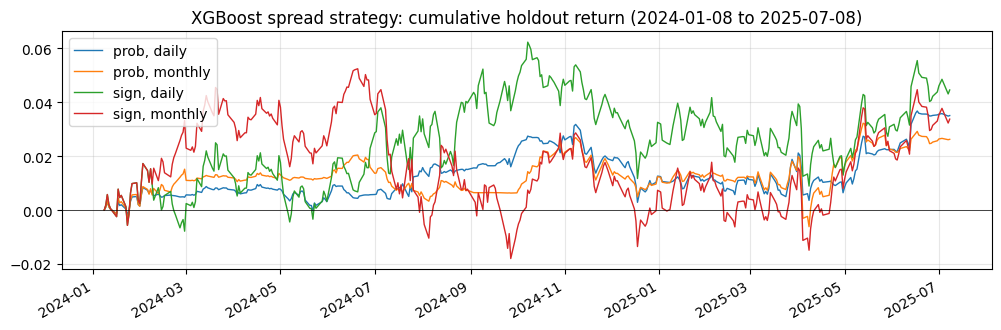

,Sharpe,Ann. return,Ann. vol,Total return,Max drawdown,In market
"prob, daily",0.762,0.024,0.031,0.035,-0.029,0.997
"prob, monthly",0.560,0.018,0.031,0.026,-0.033,0.997
"sign, daily",0.413,0.030,0.072,0.041,-0.053,0.997
"sign, monthly",0.313,0.023,0.072,0.030,-0.069,0.997


In [11]:
corn_h, soy_h = d_final.loc[holdout_idx, IND], d_final.loc[holdout_idx, DEP]
gamma_h = d_final.loc[holdout_idx, 'kf_hedge_ratio']

bt = {f'{method}, {freq}': run_backtest(prob_holdout, gamma_h, corn_h, soy_h, all_dates=holdout_idx,
                                        trade_freq=freq, method=method)
      for method in ['prob', 'sign'] for freq in ['daily', 'monthly']}
ml_backtest = pd.DataFrame({k: performance(r['daily_ret']) for k, r in bt.items()}).T
save_table(ml_backtest, '04_ml_holdout_backtest')

fig, ax = plt.subplots(figsize=(12, 3.5))
for k, r in bt.items():
    r['cum_ret'].plot(ax=ax, lw=1, label=k)
ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3); ax.legend(); ax.set_xlabel('')
ax.set_title(f'XGBoost spread strategy: cumulative holdout return ({holdout_idx[0].date()} to {holdout_idx[-1].date()})')
save_figure(fig, 'ml_holdout_returns')
plt.show()
ml_backtest.round(3)

**Market neutrality.** A hedged spread strategy should not load on the legs. We regress the daily holdout P&L on the
daily price changes of corn and soybean.

In [12]:
for k in ['sign, daily', 'sign, monthly']:
    market_neutrality(bt[k]['daily_pnl'], corn_h, soy_h, label=k)

=== sign, daily ===
  n = 374  |  beta_corn = -0.2892 (t = -4.91)  beta_soy = +0.3448 (t = +6.97)  R^2 = 0.116
=== sign, monthly ===
  n = 374  |  beta_corn = -0.1262 (t = -2.05)  beta_soy = +0.1898 (t = +3.67)  R^2 = 0.035


**Take-aways.**
* Weather carries a little information in walk-forward CV: accuracy rises from 50% with the six non-weather features
  to 55% with weather, and feature selection improves the log-loss slightly. Hyperparameter tuning adds nothing: the
  default configuration is already the best, and `max_depth` does not matter because, with uniqueness-weighted
  samples, the `min_child_weight` constraint stops the trees first.
* The signal is unstable over time: the first CV fold (2017–2020) has an accuracy below 50%, the second (2020–2023)
  about 62%.
* On the holdout XGBoost is right about 60% of the time, but its log-loss is worse than a coin flip: the
  probabilities are over-confident. The random forest is no better than always predicting the majority class.
* The holdout backtest earns Sharpe ratios of 0.3–0.8, but over only 1.5 years (standard error ≈ 0.9), with a net
  long exposure to soybean (significant loading in the market-neutrality regression), and the numbers are fragile:
  purging just four observations at the dev/holdout boundary moved them by about 0.2. This is not evidence of a
  tradeable edge.